# **Software Defect Prediction Using Machine Learning**

**1. Importing Required Libraries**

In [2]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score


from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from xgboost import XGBClassifier


from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


import joblib

**2. Loading the Dataset**

In [3]:
# Load datasets

train = pd.read_csv("/content/train.csv")

test = pd.read_csv("/content/test.csv")


print("Train shape:", train.shape)

print("Test shape:", test.shape)

Train shape: (101763, 23)
Test shape: (67842, 22)


**3. Understanding the Dataset**

In [4]:
train.head()

,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,0,22.0,3.0,1.0,2.0,60.0,278.63,0.06,19.56,14.25,...,17,1,1,0,16.0,9.0,38.0,22.0,5.0,False
1,1,14.0,2.0,1.0,2.0,32.0,151.27,0.14,7.00,21.11,...,11,0,1,0,11.0,11.0,18.0,14.0,3.0,False
2,2,11.0,2.0,1.0,2.0,45.0,197.65,0.11,8.05,22.76,...,8,0,1,0,12.0,11.0,28.0,17.0,3.0,False
3,3,8.0,1.0,1.0,1.0,23.0,94.01,0.19,5.25,17.86,...,4,0,2,0,8.0,6.0,16.0,7.0,1.0,True
4,4,11.0,2.0,1.0,2.0,17.0,60.94,0.18,5.63,12.44,...,7,0,2,0,7.0,6.0,10.0,10.0,3.0,False


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101763 entries, 0 to 101762
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 101763 non-null  int64  
 1   loc                101763 non-null  float64
 2   v(g)               101763 non-null  float64
 3   ev(g)              101763 non-null  float64
 4   iv(g)              101763 non-null  float64
 5   n                  101763 non-null  float64
 6   v                  101763 non-null  float64
 7   l                  101763 non-null  float64
 8   d                  101763 non-null  float64
 9   i                  101763 non-null  float64
 10  e                  101763 non-null  float64
 11  b                  101763 non-null  float64
 12  t                  101763 non-null  float64
 13  lOCode             101763 non-null  int64  
 14  lOComment          101763 non-null  int64  
 15  lOBlank            101763 non-null  int64  
 16  lo

In [6]:
train.describe()

,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,...,t,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount
count,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,...,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000
mean,50881.000000,37.347160,5.492684,2.845022,3.498826,96.655995,538.280956,0.111634,13.681881,27.573007,...,1141.357982,22.802453,1.773945,3.979865,0.196604,11.896131,15.596671,57.628116,39.249698,9.839549
std,29376.592059,54.600401,7.900855,4.631262,5.534541,171.147191,1270.791601,0.100096,14.121306,22.856742,...,9862.795472,38.541010,5.902412,6.382358,0.998906,6.749549,18.064261,104.537660,71.692309,14.412769
min,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,25440.500000,13.000000,2.000000,1.000000,1.000000,25.000000,97.670000,0.050000,5.600000,15.560000,...,31.380000,7.000000,0.000000,1.000000,0.000000,8.000000,7.000000,15.000000,10.000000,3.000000
50%,50881.000000,22.000000,3.000000,1.000000,2.000000,51.000000,232.790000,0.090000,9.820000,23.360000,...,125.400000,14.000000,0.000000,2.000000,0.000000,11.000000,12.000000,30.000000,20.000000,5.000000
75%,76321.500000,42.000000,6.000000,3.000000,4.000000,111.000000,560.250000,0.150000,18.000000,34.340000,...,565.920000,26.000000,1.000000,5.000000,0.000000,16.000000,20.000000,66.000000,45.000000,11.000000
max,101762.000000,3442.000000,404.000000,165.000000,402.000000,8441.000000,80843.080000,1.000000,418.200000,569.780000,...,935923.390000,2824.000000,344.000000,219.000000,43.000000,410.000000,1026.000000,5420.000000,3021.000000,503.000000


In [7]:
train.columns

Index(['id', 'loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e',
       'b', 't', 'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment',
       'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount',
       'defects'],
      dtype='object')

In [8]:
train["defects"].value_counts()

,count
defects,
False,78699
True,23064


In [9]:
# Convert target values into binary format

train["defects"] = train["defects"].astype(int)

**4. Exploratory Data Analysis (EDA)**

In [10]:
train.isnull().sum()
test.isnull().sum()

,0
id,0
loc,0
v(g),0
ev(g),0
iv(g),0
n,0
v,0
l,0
d,0
i,0


In [11]:
# Replace missing values with column mean

train = train.fillna(train.mean())

test = test.fillna(test.mean())

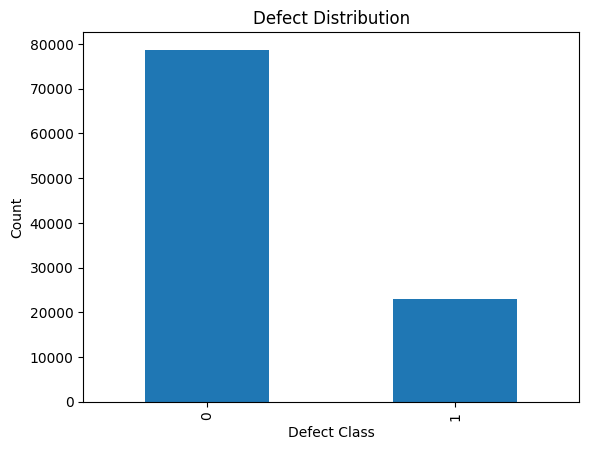

In [12]:
train["defects"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Defect Class")

plt.ylabel("Count")

plt.title("Defect Distribution")

plt.show()

In [13]:
correlation = train.corr()["defects"].sort_values()

correlation

,defects
l,-0.253237
id,0.001976
e,0.095366
t,0.099592
locCodeAndComment,0.133150
uniq_Op,0.178474
lOComment,0.205402
i,0.208577
v,0.231179
b,0.232594


In [14]:
correlation.tail(10)

,defects
total_Op,0.250533
lOCode,0.250604
total_Opnd,0.252752
lOBlank,0.257819
n,0.258080
ev(g),0.259928
v(g),0.301187
branchCount,0.322827
loc,0.342642
defects,1.000000


**5. Data Preprocessing**

In [15]:
X = train.drop(
    "defects",
    axis=1
)


y = train["defects"]

In [16]:
test_data = test.copy()

**6. Splitting Data for Training and Testing**

In [17]:
# Stratified split keeps defect ratio similar in both sets

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
print(X_train.shape)

print(X_valid.shape)

(81410, 22)
(20353, 22)


In [19]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_valid_scaled = scaler.transform(
    X_valid
)

In [20]:
X_train_scaled.shape

(81410, 22)

**7. Training Machine Learning Models**

In [21]:
# Comparing different classification models

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),


    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),


    "XGBoost": XGBClassifier(
        random_state=42
    )

}

**8. Model Evaluation Using Performance Metrics**

In [22]:
def evaluate_model(name, model):

    model.fit(
        X_train_scaled,
        y_train
    )


    prediction = model.predict(
        X_valid_scaled
    )


    probability = model.predict_proba(
        X_valid_scaled
    )[:,1]


    accuracy = accuracy_score(
        y_valid,
        prediction
    )


    precision = precision_score(
        y_valid,
        prediction
    )


    recall = recall_score(
        y_valid,
        prediction
    )


    f1 = f1_score(
        y_valid,
        prediction
    )


    roc_auc = roc_auc_score(
        y_valid,
        probability
    )


    return [
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

In [23]:
results = []


for name, model in models.items():

    result = evaluate_model(
        name,
        model
    )

    results.append(result)

**9. Comparing Model Performance**

In [24]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)


results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.808333,0.708675,0.262085,0.382655,0.780550
1,Random Forest,0.811870,0.647590,0.372859,0.473243,0.777099
2,XGBoost,0.807694,0.628445,0.370692,0.466321,0.779887


**10. Selecting the Best Performing Model**

In [25]:
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.811870,0.647590,0.372859,0.473243,0.777099
2,XGBoost,0.807694,0.628445,0.370692,0.466321,0.779887
0,Logistic Regression,0.808333,0.708675,0.262085,0.382655,0.780550


In [29]:
# Final selected model based on F1 score

best_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


best_model.fit(
    X_train_scaled,
    y_train
)

RandomForestClassifier(random_state=42)

**11. Evaluating the Selected Model**

In [30]:
prediction = best_model.predict(
    X_valid_scaled
)


probability = best_model.predict_proba(
    X_valid_scaled
)[:,1]

In [31]:
print(
    "Accuracy:",
    accuracy_score(
        y_valid,
        prediction
    )
)


print(
    "Precision:",
    precision_score(
        y_valid,
        prediction
    )
)


print(
    "Recall:",
    recall_score(
        y_valid,
        prediction
    )
)


print(
    "F1 Score:",
    f1_score(
        y_valid,
        prediction
    )
)


print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid,
        probability
    )
)

Accuracy: 0.8118704859234511
Precision: 0.6475903614457831
Recall: 0.37285931064383265
F1 Score: 0.4732425368001101
ROC-AUC: 0.777098896797653


In [32]:
print(
    classification_report(
        y_valid,
        prediction
    )
)

              precision    recall  f1-score   support

           0       0.84      0.94      0.89     15740
           1       0.65      0.37      0.47      4613

    accuracy                           0.81     20353
   macro avg       0.74      0.66      0.68     20353
weighted avg       0.79      0.81      0.79     20353



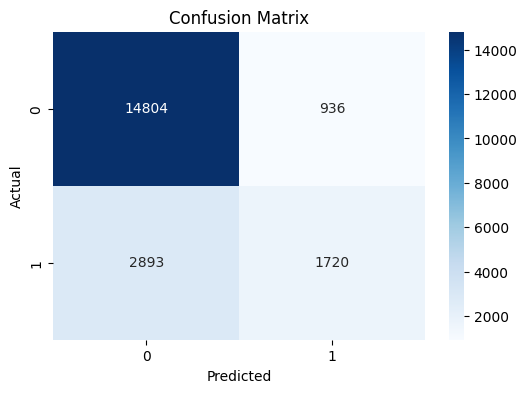

In [36]:
import seaborn as sns


cm = confusion_matrix(
    y_valid,
    prediction
)


plt.figure(figsize=(6,4))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.title(
    "Confusion Matrix"
)


plt.show()

**12. Cross-Validation of the Selected Model**

In [37]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [39]:
cv_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)


f1_scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=cv,
    scoring="f1"
)


print(f1_scores)


print(
    "Average F1 Score:",
    f1_scores.mean()
)

[0.46988621 0.47199014 0.45378612 0.46176952 0.47084648]
Average F1 Score: 0.46565569308407345


In [40]:
auc_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)


print(
    auc_scores
)


print(
    "Average ROC-AUC:",
    auc_scores.mean()
)

[0.77685798 0.77452378 0.76862607 0.77434673 0.77571417]
Average ROC-AUC: 0.7740137454394274


**13. Feature Importance Analysis**

In [41]:
importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }
)


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


importance.head(10)

,Feature,Importance
1,loc,0.127398
0,id,0.087432
2,v(g),0.054840
9,i,0.052250
6,v,0.052098
12,t,0.049110
10,e,0.048143
13,lOCode,0.047942
4,iv(g),0.046380
8,d,0.045898


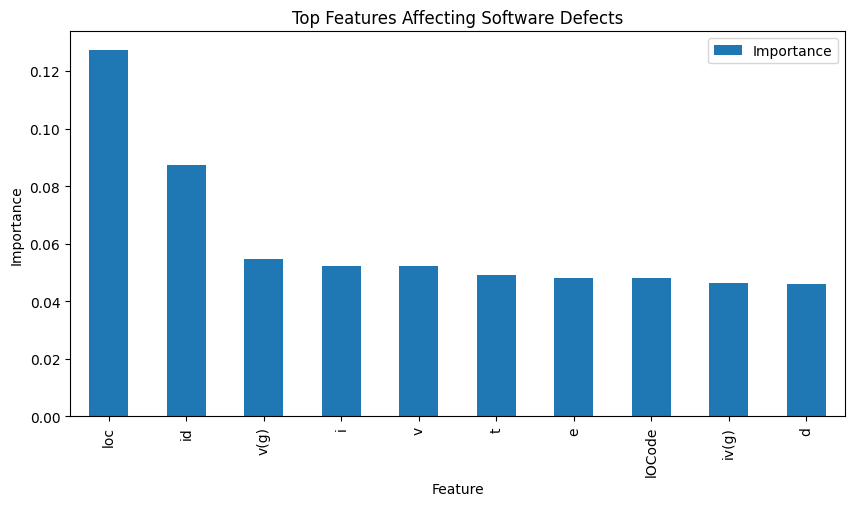

In [42]:
importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)


plt.title(
    "Top Features Affecting Software Defects"
)


plt.ylabel(
    "Importance"
)


plt.show()

**14. Training the Final Model**

In [43]:
# Scaling complete training data

final_scaler = StandardScaler()


X_full_scaled = final_scaler.fit_transform(
    X
)


test_scaled = final_scaler.transform(
    test_data
)

In [44]:
# Train final model using complete training data

final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


final_model.fit(
    X_full_scaled,
    y
)

RandomForestClassifier(random_state=42)

In [45]:
test_prediction = final_model.predict(
    test_scaled
)


test_probability = final_model.predict_proba(
    test_scaled
)[:,1]

In [46]:
prediction_report = pd.DataFrame()


prediction_report["id"] = test_data["id"]


prediction_report["Defect Probability (%)"] = (
    test_probability * 100
).round(2)


prediction_report["Prediction"] = test_prediction


prediction_report.head()

,id,Defect Probability (%),Prediction
0,101763,45.0,0
1,101764,39.0,0
2,101765,69.0,1
3,101766,62.0,1
4,101767,31.0,0


In [47]:
prediction_report["Prediction"] = prediction_report[
    "Prediction"
].replace(
    {
        0:"No Defect",
        1:"Defect"
    }
)


prediction_report.head()

,id,Defect Probability (%),Prediction
0,101763,45.0,No Defect
1,101764,39.0,No Defect
2,101765,69.0,Defect
3,101766,62.0,Defect
4,101767,31.0,No Defect


In [48]:
def risk_level(value):

    if value < 30:
        return "Low Risk"

    elif value < 70:
        return "Medium Risk"

    else:
        return "High Risk"

In [49]:
prediction_report["Risk Level"] = prediction_report[
    "Defect Probability (%)"
].apply(
    risk_level
)


prediction_report.head()

,id,Defect Probability (%),Prediction,Risk Level
0,101763,45.0,No Defect,Medium Risk
1,101764,39.0,No Defect,Medium Risk
2,101765,69.0,Defect,Medium Risk
3,101766,62.0,Defect,Medium Risk
4,101767,31.0,No Defect,Medium Risk


In [50]:
prediction_report["Quality Score"] = (
    100 - prediction_report["Defect Probability (%)"]
).round(2)


prediction_report.head()

,id,Defect Probability (%),Prediction,Risk Level,Quality Score
0,101763,45.0,No Defect,Medium Risk,55.0
1,101764,39.0,No Defect,Medium Risk,61.0
2,101765,69.0,Defect,Medium Risk,31.0
3,101766,62.0,Defect,Medium Risk,38.0
4,101767,31.0,No Defect,Medium Risk,69.0


In [51]:
def recommendation(level):

    if level == "High Risk":
        return "Needs immediate code review and testing"

    elif level == "Medium Risk":
        return "Review module and perform additional testing"

    else:
        return "Module quality looks good"


prediction_report["Recommendation"] = prediction_report[
    "Risk Level"
].apply(
    recommendation
)


prediction_report.head()

,id,Defect Probability (%),Prediction,Risk Level,Quality Score,Recommendation
0,101763,45.0,No Defect,Medium Risk,55.0,Review module and perform additional testing
1,101764,39.0,No Defect,Medium Risk,61.0,Review module and perform additional testing
2,101765,69.0,Defect,Medium Risk,31.0,Review module and perform additional testing
3,101766,62.0,Defect,Medium Risk,38.0,Review module and perform additional testing
4,101767,31.0,No Defect,Medium Risk,69.0,Review module and perform additional testing


In [52]:
prediction_report.head(10)

,id,Defect Probability (%),Prediction,Risk Level,Quality Score,Recommendation
0,101763,45.0,No Defect,Medium Risk,55.0,Review module and perform additional testing
1,101764,39.0,No Defect,Medium Risk,61.0,Review module and perform additional testing
2,101765,69.0,Defect,Medium Risk,31.0,Review module and perform additional testing
3,101766,62.0,Defect,Medium Risk,38.0,Review module and perform additional testing
4,101767,31.0,No Defect,Medium Risk,69.0,Review module and perform additional testing
5,101768,39.0,No Defect,Medium Risk,61.0,Review module and perform additional testing
6,101769,44.0,No Defect,Medium Risk,56.0,Review module and perform additional testing
7,101770,35.0,No Defect,Medium Risk,65.0,Review module and perform additional testing
8,101771,51.0,Defect,Medium Risk,49.0,Review module and perform additional testing
9,101772,15.0,No Defect,Low Risk,85.0,Module quality looks good


**15. Saving the Trained Model and Scaler**

In [56]:
import joblib


joblib.dump(
    final_model,
    "software_defect_model.pkl"
)


joblib.dump(
    final_scaler,
    "scaler.pkl"
)


print("Model and scaler saved successfully")

Model and scaler saved successfully


In [57]:
import os

os.listdir()

['.config',
 'train.csv',
 '.ipynb_checkpoints',
 'software_defect_model.pkl',
 'scaler.pkl',
 'test.csv',
 'software_defect_analysis_report.csv',
 'sample_data']

**16. User CSV Upload for Prediction**

In [58]:
from google.colab import files


uploaded = files.upload()

Saving prinput.xlsx to prinput.xlsx


**17. Loading User Input Data**

In [60]:
import os


file_name = list(uploaded.keys())[0]


user_data = pd.read_excel(
    file_name
)

user_data.head()

,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,...,t,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount
0,101,25,3,2,2,70,300.5,0.08,20.5,15.2,...,320.5,20,2,3,1,18,10,45,25,6
1,102,60,8,5,6,250,1200.2,0.03,45.2,22.4,...,1500.2,55,5,8,3,30,18,120,70,20
2,103,15,2,1,1,35,140.6,0.15,8.1,18.7,...,60.4,12,1,2,0,10,8,25,15,3
3,104,120,15,10,12,500,2500.8,0.02,70.3,30.1,...,4000.7,110,10,15,8,45,25,250,150,40
4,105,45,6,4,5,180,850.4,0.05,35.6,25.8,...,900.6,40,4,6,2,25,15,90,55,15


**18. Validating User Input Data**

In [61]:
# Check whether required features are present

required_features = X.columns.tolist()


missing_columns = set(required_features) - set(user_data.columns)


if len(missing_columns) > 0:

    print(
        "Missing columns:",
        missing_columns
    )

else:

    print(
        "CSV format is correct"
    )

CSV format is correct


**19. Preprocessing User Input**

In [62]:
user_ids = user_data["id"]


user_features = user_data[
    required_features
]

In [63]:
user_scaled = final_scaler.transform(
    user_features
)

**20. Predicting Software Defects**

In [64]:
user_prediction = final_model.predict(
    user_scaled
)


user_probability = final_model.predict_proba(
    user_scaled
)[:,1]

**21. Generating the Software Defect Prediction Report**

In [65]:
user_report = pd.DataFrame()


user_report["id"] = user_ids


user_report["Defect Probability (%)"] = (
    user_probability * 100
).round(2)


user_report["Prediction"] = user_prediction


user_report.head()

,id,Defect Probability (%),Prediction
0,101,24.0,0
1,102,43.0,0
2,103,21.0,0
3,104,63.0,1
4,105,49.0,0


In [66]:
user_report["Prediction"] = user_report[
    "Prediction"
].replace(
    {
        0:"No Defect",
        1:"Defect"
    }
)


user_report.head()

,id,Defect Probability (%),Prediction
0,101,24.0,No Defect
1,102,43.0,No Defect
2,103,21.0,No Defect
3,104,63.0,Defect
4,105,49.0,No Defect


In [67]:
user_report["Risk Level"] = user_report[
    "Defect Probability (%)"
].apply(
    risk_level
)


user_report.head()

,id,Defect Probability (%),Prediction,Risk Level
0,101,24.0,No Defect,Low Risk
1,102,43.0,No Defect,Medium Risk
2,103,21.0,No Defect,Low Risk
3,104,63.0,Defect,Medium Risk
4,105,49.0,No Defect,Medium Risk


In [68]:
user_report["Quality Score"] = (
    100 - user_report["Defect Probability (%)"]
).round(2)


user_report.head()

,id,Defect Probability (%),Prediction,Risk Level,Quality Score
0,101,24.0,No Defect,Low Risk,76.0
1,102,43.0,No Defect,Medium Risk,57.0
2,103,21.0,No Defect,Low Risk,79.0
3,104,63.0,Defect,Medium Risk,37.0
4,105,49.0,No Defect,Medium Risk,51.0


In [69]:
user_report["Recommendation"] = user_report[
    "Risk Level"
].apply(
    recommendation
)


user_report.head()

,id,Defect Probability (%),Prediction,Risk Level,Quality Score,Recommendation
0,101,24.0,No Defect,Low Risk,76.0,Module quality looks good
1,102,43.0,No Defect,Medium Risk,57.0,Review module and perform additional testing
2,103,21.0,No Defect,Low Risk,79.0,Module quality looks good
3,104,63.0,Defect,Medium Risk,37.0,Review module and perform additional testing
4,105,49.0,No Defect,Medium Risk,51.0,Review module and perform additional testing


In [70]:
user_report

,id,Defect Probability (%),Prediction,Risk Level,Quality Score,Recommendation
0,101,24.0,No Defect,Low Risk,76.0,Module quality looks good
1,102,43.0,No Defect,Medium Risk,57.0,Review module and perform additional testing
2,103,21.0,No Defect,Low Risk,79.0,Module quality looks good
3,104,63.0,Defect,Medium Risk,37.0,Review module and perform additional testing
4,105,49.0,No Defect,Medium Risk,51.0,Review module and perform additional testing
5,106,60.0,Defect,Medium Risk,40.0,Review module and perform additional testing
6,107,29.0,No Defect,Low Risk,71.0,Module quality looks good
7,108,66.0,Defect,Medium Risk,34.0,Review module and perform additional testing


**22. Exporting Prediction Results**

In [71]:
user_report.to_csv(
    "defect_prediction_result.csv",
    index=False
)


files.download(
    "defect_prediction_result.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>